In [57]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import libpysal
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

# Procesamiento de Datos

Este notebook implementa el pipeline completo de limpieza y consolidacion para el analisis espacial de delitos en la Ciudad de Mexico (2019 - 2024).

**Fuentes de datos utilizadas:**
- `reportes_incidenciasU.geojson`: carétas de investigación georreferencias. Origen: Fiscalia General de Justicia de la CDMX.
- `GeoColonias.geojson`: poligonos de las colonias de la CDMX.
- `DemograficosD_GJ.geojson`: variables demograficas por colonias (poblacio 2010, superficie, entre otros).
- `aglomeracionesU.geojson` y `camaraPosU.geojson`: fuentes auxiliares a utilizar para la siguiente entrega.


In [58]:
aglomeraciones = gpd.read_file("aglomeracionesU.geojson")
demograficos   = gpd.read_file("DemograficosD_GJ.geojson")
colonias       = gpd.read_file("GeoColonias.geojson")
incidencias    = gpd.read_file("reportes_incidenciaU.geojson")
camaras        = gpd.read_file("camaraPosU.geojson")

In [59]:
def revisar_dataset(demografico_final, nombre):
    print(f"\n--- {nombre} ---")
    print(f"Dimensiones: {demografico_final.shape}")
    print(f"CRS: {demografico_final.crs}")

    print("\nInformación general:")
    print(demografico_final.info())

    print("\nPrimeras filas:")
    print(demografico_final.head(3))

    print("\nValores nulos por columna:")
    print(demografico_final.isnull().sum())

    #print(f"\nDuplicados: {demografico_final.duplicated().sum()}")

revisar_dataset(aglomeraciones, "Aglomeraciones")
revisar_dataset(demograficos, "Demográficos")
revisar_dataset(colonias, "Colonia")
revisar_dataset(incidencias, "Incidencias")
revisar_dataset(camaras, "Cámaras")


--- Aglomeraciones ---
Dimensiones: (251892, 10)
CRS: EPSG:32614

Información general:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 251892 entries, 0 to 251891
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id          251892 non-null  int32   
 1   nom_estab   251892 non-null  str     
 2   nombre_act  251892 non-null  str     
 3   alcaldia    251687 non-null  str     
 4   cve_col     251687 non-null  str     
 5   colonia     251687 non-null  str     
 6   latitud     251892 non-null  float64 
 7   longitud    251892 non-null  float64 
 8   cat_act     251892 non-null  str     
 9   geometry    251892 non-null  geometry
dtypes: float64(2), geometry(1), int32(1), str(6)
memory usage: 18.3 MB
None

Primeras filas:
        id                 nom_estab  \
0   742945  20 ABARROTES DON ARMANDO   
1  9041142                     2 X U   
2  8332695   2000_CVS BIM CENTENARIO   

                      

In [60]:
datasets = {
    "aglomeraciones": aglomeraciones,
    "demograficos": demograficos,
    "colonias": colonias,
    "Incidencias": incidencias,
    "camaras": camaras
}

resumen = pd.DataFrame([
    {
        "Dataset": nombre,
        "Filas": df.shape[0],
        "Columnas": df.shape[1],
        "Valores nulos": df.isnull().sum().sum(),
    }
    for nombre, df in datasets.items()
])

display(resumen)

,Dataset,Filas,Columnas,Valores nulos
0,aglomeraciones,251892,10,615
1,demograficos,1815,10,3
2,colonias,1815,4,3
3,Incidencias,1319593,12,5265
4,camaras,14745,9,110


### Seleccion de fuentes relevantes

De las cinco fuentes cargadas, el analisis se centra en tres: incidencias (registros de delitos), colonias (unidad espacial de analisis) y demograficos (variables de control). Las fuentes de aglomeraciones y camaras quedan disponibles como predictoras en la entrega final.

### 1.1 Filtro de registros de Incidencias

Se aplican dos filtros secuenciales:

1. Filtro por tipo de impacto: se retienen unicamente los registros clasificados como `DELITO DE ALTO IMPACTO`, categoria que agrupa los delitos de mayor gravedad.
2. Filtro temporal: se acota el analisis al periodo 2019-2024, excluyendo años anteriores.

In [61]:
# Filtro 1: Delitos de Alto Impacto
incidencias_filtrada = incidencias[incidencias["impacto_delito"] == "DELITO DE ALTO IMPACTO"].copy()

# Filtro 2: Rango de años (2019 - 2024)
INICIO, FIN = 2019, 2024
incidencias_filtrada = incidencias_filtrada[incidencias_filtrada["anio_hecho"].between(INICIO, FIN)]

print(f"Delitos iniciales:                    {len(incidencias)}")
print(f"Delitos tras filtros de impacto y año: {len(incidencias_filtrada)}")

Delitos iniciales:                    1319593
Delitos tras filtros de impacto y año: 189599


In [62]:
revisar_dataset(incidencias_filtrada, "incidencias_filtrada")


--- incidencias_filtrada ---
Dimensiones: (189599, 12)
CRS: EPSG:32614

Información general:


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 189599 entries, 3 to 1319584
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   id_delito         189599 non-null  str     
 1   delito            189599 non-null  str     
 2   categoria_delito  189599 non-null  str     
 3   impacto_delito    189599 non-null  str     
 4   anio_hecho        189599 non-null  int32   
 5   mes_hecho         189599 non-null  str     
 6   alcaldia          189435 non-null  str     
 7   cve_col           189435 non-null  str     
 8   colonia           189435 non-null  str     
 9   latitud           189599 non-null  float64 
 10  longitud          189599 non-null  float64 
 11  geometry          189599 non-null  geometry
dtypes: float64(2), geometry(1), int32(1), str(8)
memory usage: 18.1 MB
None

Primeras filas:
              id_delito                                             delito  \
3    2019Enero06:00:003  RO

### 1.2 Eliminacion de registros sin asignacion temporal

Tras el filtrado, se identificaron 164 registros sin clave de colonia. Estos casos son eventos georreferenciados que caen fuera de los limites de las colonias disponibles. Por lo que los registros fueron eliminados del dataset

In [63]:
incidencias_filtrada = incidencias_filtrada.dropna(
    subset=["cve_col", "colonia", "alcaldia"]
).copy()

### 1.3 Extracción de la hora del hecho

El dataset de incidencias no incluye hora del delito, pero si esta codificada dentro del campo "id_delito". Se define una expresion para extraerla, generando la columna "hora_hecho" con valores enteros entre 0 y 23.

Finalmente, se seleccionan unicamente las columnas relevantes para el analisis.

In [64]:
def extraer_hora(id_delito):
    match = re.search(r'(\d{2}):\d{2}', str(id_delito))
    if match:
        return int(match.group(1))
    return None

incidencias_filtrada["hora_hecho"] = incidencias_filtrada["id_delito"].apply(extraer_hora)

columnas_finales = ["id_delito", "delito", "categoria_delito", 
                    "anio_hecho", "mes_hecho", "hora_hecho", 
                    "alcaldia", "cve_col", "colonia", 
                    "latitud", "longitud", "geometry"]

incidencias_final = incidencias_filtrada[columnas_finales].copy()

print(f"Delitos tras limpieza: {len(incidencias_final)}")

Delitos tras limpieza: 189435


### 1.4 Construccion del dataset consolidado por colonia

Con el dataset de incidencias depurado, se construye el dataset analitico final:

1. Agregacion por colonia: se cuenta el numero de delitos por colonia.

2. Limpieza de colonias: se eliminan registros con valores nuelos en los identficadores territoriales (es solo un dato).

3. Incorportacion de var. demograficas: se une la información del Censo 2010 por colonia, añadiendo población total, superficie, número de viviendas y densidad de vivienda por hectarea.


In [65]:
delitos_colonia = (
    incidencias_final
    .groupby(
        ["cve_col", "colonia", "alcaldia"]
    )
    .size()
    .reset_index(name="n_delitos")
)

display(delitos_colonia.head())

,cve_col,colonia,alcaldia,n_delitos
0,02-001,AGUILERA,AZCAPOTZALCO,28
1,02-002,ALDANA,AZCAPOTZALCO,51
2,02-003,PETROLERA (AMPL),AZCAPOTZALCO,58
3,02-005,ANGEL ZIMBRON,AZCAPOTZALCO,132
4,02-006,ARENAL,AZCAPOTZALCO,91


In [66]:
colonias_base = colonias.dropna(
    subset=["cve_col", "colonia", "alcaldia"]
).copy()

In [67]:
dataset_intermedio = colonias_base.merge(
    delitos_colonia,
    on=["cve_col", "colonia", "alcaldia"],
    how="left"
)

dataset_intermedio["n_delitos"] = dataset_intermedio["n_delitos"].fillna(0)

print(dataset_intermedio["n_delitos"].describe())

demografico_final = dataset_intermedio.merge(
    demograficos[["cve_col", "pob_2010", "SUP_COL_M2", "VIV2010", "DENVIVHa"]],
    on="cve_col",
    how="left"
)

print("\n--- RESUMEN DATASET FINAL CONSOLIDADO ---")
print(demografico_final.info())
demografico_final.head()

count    1814.000000
mean      104.429438
std       133.016773
min         0.000000
25%        21.000000
50%        61.000000
75%       146.000000
max      1557.000000
Name: n_delitos, dtype: float64

--- RESUMEN DATASET FINAL CONSOLIDADO ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1814 entries, 0 to 1813
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   alcaldia    1814 non-null   str     
 1   cve_col     1814 non-null   str     
 2   colonia     1814 non-null   str     
 3   geometry    1814 non-null   geometry
 4   n_delitos   1814 non-null   float64 
 5   pob_2010    1814 non-null   float64 
 6   SUP_COL_M2  1814 non-null   float64 
 7   VIV2010     1814 non-null   int32   
 8   DENVIVHa    1814 non-null   float64 
dtypes: float64(4), geometry(1), int32(1), str(3)
memory usage: 120.6 KB
None


,alcaldia,cve_col,colonia,geometry,n_delitos,pob_2010,SUP_COL_M2,VIV2010,DENVIVHa
0,AZCAPOTZALCO,02-001,AGUILERA,"POLYGON ((483311.618 2153254.848, 483332.006 2...",28.0,2014.0,103825.0,680,65.4948
1,AZCAPOTZALCO,02-002,ALDANA,"POLYGON ((484406.956 2153012.331, 484401.132 2...",51.0,3378.0,154812.0,1088,70.2788
2,AZCAPOTZALCO,02-005,ANGEL ZIMBRON,"POLYGON ((480275.324 2152244.351, 480267.968 2...",132.0,2737.0,242232.0,1067,44.0487
3,AZCAPOTZALCO,02-006,ARENAL,"POLYGON ((484061.118 2152622.284, 484061.678 2...",91.0,4817.0,286075.0,1493,52.1891
4,AZCAPOTZALCO,02-007,CENTRO DE AZCAPOTZALCO,"POLYGON ((480104.707 2154525.214, 480118.178 2...",300.0,3043.0,424471.0,1118,26.3387


### 1.5 Pivot por tipo de delito

Se agrega el conteo de delito por colonia y tipo de delito, generando una columna por tipo. Esto permite comparar si distintos delitos presentan patrones espaciales distintos.

In [68]:
# Conteo por colonia Y tipo de delito
conteo_tipo = (
    incidencias_final
    .groupby(['cve_col', 'delito'])
    .size()
    .reset_index(name='n')
)

# Pivot: filas = colonias, columnas = tipos de delito
pivot = (
    conteo_tipo
    .pivot_table(index='cve_col', columns='delito', values='n', fill_value=0)
    .reset_index()
)

# Limpiar nombres de columnas
pivot.columns.name = None

# Unir al GeoDataFrame de colonias
demografico_final = demografico_final.merge(pivot, on='cve_col', how='left')

# Rellenar NaN (colonias sin ese tipo de delito) con 0
tipos_delito = list(pivot.columns[1:])  # excluye cve_col
demografico_final[tipos_delito] = demografico_final[tipos_delito].fillna(0)

print(f'Tipos de delito agregados como columnas: {len(tipos_delito)}')
print('Primeros tipos:', tipos_delito[:5])
demografico_final[['colonia', 'n_delitos'] + tipos_delito[:3]].head(5)

Tipos de delito agregados como columnas: 64
Primeros tipos: ['FEMINICIDIO', 'FEMINICIDIO POR ARMA BLANCA', 'FEMINICIDIO POR DISPARO DE ARMA DE FUEGO', 'FEMINICIDIO POR GOLPES', 'HOMICIDIO POR AHORCAMIENTO']


,colonia,n_delitos,FEMINICIDIO,FEMINICIDIO POR ARMA BLANCA,FEMINICIDIO POR DISPARO DE ARMA DE FUEGO
0,AGUILERA,28.0,0.0,0.0,0.0
1,ALDANA,51.0,0.0,0.0,0.0
2,ANGEL ZIMBRON,132.0,0.0,0.0,0.0
3,ARENAL,91.0,0.0,0.0,0.0
4,CENTRO DE AZCAPOTZALCO,300.0,0.0,0.0,0.0


### 1.6 Variables derivadas

Se construyen tres tipos de variables a partir del conteo bruto de delitos:

1. Tasa por 100,000 habitantes: permite comparar colonias con distinta poblacion

2. Densidades por km^2: capturar la concentracion espacial

3. Tasas por tipo de delito (top 5): una tasa individual para cada uno de los cinco delitos mas frecuentes.

In [69]:
# ── Ajusta si tus columnas tienen otro nombre ─────────────────────────────────
COL_POB   = 'pob_2010'    # población
COL_SUP   = 'SUP_COL_M2'  # superficie en m²
COL_VIV   = 'VIV2010'     # viviendas
# ─────────────────────────────────────────────────────────────────────────────

# Área en km²
demografico_final['area_km2'] = demografico_final[COL_SUP] / 1_000_000

# Tasa TOTAL por 100k hab.
demografico_final['tasa_100k'] = np.where(
    demografico_final[COL_POB] > 0,
    demografico_final['n_delitos'] / demografico_final[COL_POB] * 100_000,
    np.nan
)

# Densidad de delitos por km²
demografico_final['dens_delitos_km2'] = np.where(
    demografico_final['area_km2'] > 0,
    demografico_final['n_delitos'] / demografico_final['area_km2'],
    np.nan
)

# Densidad poblacional (predictora para GWR)
demografico_final['dens_pob_km2'] = np.where(
    demografico_final['area_km2'] > 0,
    demografico_final[COL_POB] / demografico_final['area_km2'],
    np.nan
)

# Log-transformaciones (distribución de crimen muy sesgada)
demografico_final['log_tasa']     = np.log1p(demografico_final['tasa_100k'])
demografico_final['log_dens_pob'] = np.log1p(demografico_final['dens_pob_km2'])

# Tasas por tipo de delito para los más frecuentes
top5_tipos = incidencias_final['delito'].value_counts().head(5).index.tolist()
print('Top 5 delitos:')

tasas_por_tipo = {}
for t in top5_tipos:
    col_tasa = f'tasa_{t[:20]}'
    tasas_por_tipo[col_tasa] = np.where(
        demografico_final[COL_POB] > 0,
        demografico_final[t] / demografico_final[COL_POB] * 100_000,
        np.nan
    )
    print(f'  {t[:40]:45} → columna: {col_tasa}')

demografico_final = pd.concat(
    [demografico_final, pd.DataFrame(tasas_por_tipo, index=demografico_final.index)],
    axis=1
)
# Eliminar filas sin datos válidos
demografico_clean = demografico_final.dropna(subset=['log_tasa', 'log_dens_pob', 'geometry']).copy()
demografico_clean = demografico_clean[demografico_clean[COL_POB] > 0].copy()

Top 5 delitos:
  ROBO A TRANSEUNTE EN VIA PUBLICA CON VIO      → columna: tasa_ROBO A TRANSEUNTE EN
  ROBO A NEGOCIO CON VIOLENCIA                  → columna: tasa_ROBO A NEGOCIO CON V
  ROBO DE VEHICULO DE SERVICIO PARTICULAR       → columna: tasa_ROBO DE VEHICULO DE 
  ROBO A TRANSEUNTE EN VIA PUBLICA SIN VIO      → columna: tasa_ROBO A TRANSEUNTE EN
  ROBO DE MOTOCICLETA SIN VIOLENCIA             → columna: tasa_ROBO DE MOTOCICLETA 


### 1.6.1 Justificación de la transformacion logaritimica

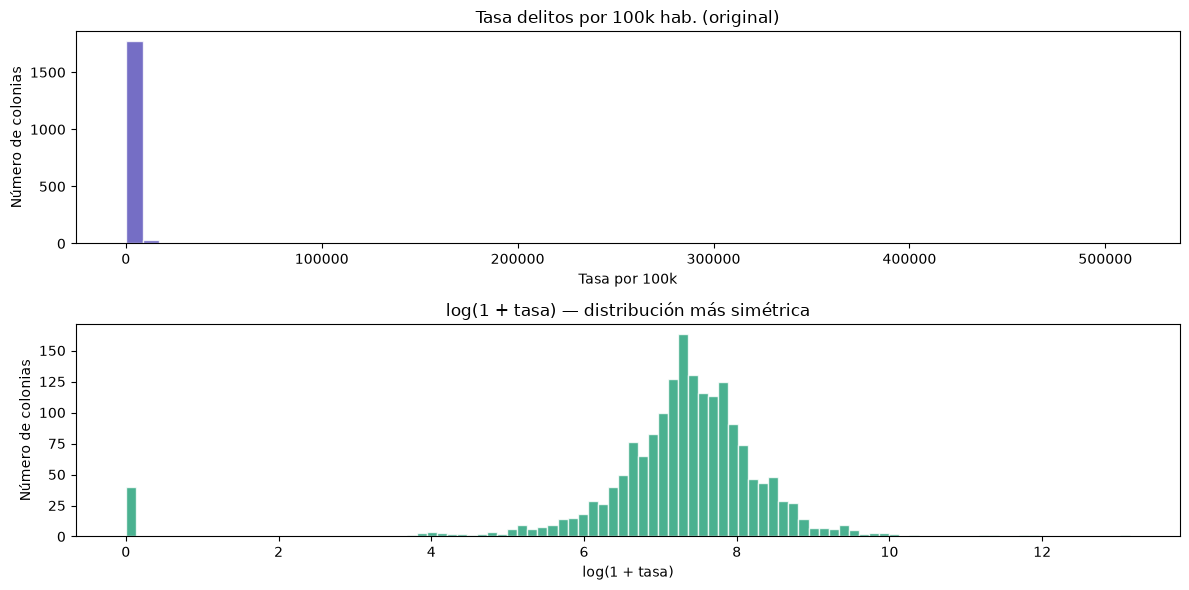

In [70]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Histograma tasa cruda
axes[0].hist(demografico_clean['tasa_100k'].dropna(), bins=60, color='#534AB7', alpha=0.8, edgecolor='white')
axes[0].set_title('Tasa delitos por 100k hab. (original)', fontsize=12)
axes[0].set_xlabel('Tasa por 100k')
axes[0].set_ylabel('Número de colonias')

# Log-tasa (más simétrica)
axes[1].hist(demografico_clean['log_tasa'].dropna(), bins=100, color='#1D9E75', alpha=0.8, edgecolor='white')
axes[1].set_title('log(1 + tasa) — distribución más simétrica', fontsize=12)
axes[1].set_xlabel('log(1 + tasa)')
axes[1].set_ylabel('Número de colonias')

plt.tight_layout()
plt.savefig('resultados/01_descriptivas.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:
demografico_clean[["colonia", "alcaldia", "n_delitos", COL_POB, "tasa_100k"]].sort_values('tasa_100k', ascending=False).head(10)

,colonia,alcaldia,n_delitos,pob_2010,tasa_100k
1799,CAROLA,ALVARO OBREGON,41.0,8.0,512500.000000
269,CIUDAD UNIVERSITARIA,COYOACAN,417.0,280.0,148928.571429
1415,INDUSTRIAL PUERTO AEREO (FRACC),VENUSTIANO CARRANZA,124.0,99.0,125252.525253
166,SAN PEDRO DE LOS PINOS,ALVARO OBREGON,101.0,110.0,91818.181818
27,INDUSTRIAL VALLEJO,AZCAPOTZALCO,316.0,428.0,73831.775701
1470,EL ROSARIO (BARR),XOCHIMILCO,198.0,627.0,31578.947368
488,TABACALERA,CUAUHTEMOC,794.0,3267.0,24303.642485
1373,7 DE JULIO,VENUSTIANO CARRANZA,277.0,1195.0,23179.916318
1389,CENTRO II,VENUSTIANO CARRANZA,1048.0,4834.0,21679.768308
1101,MOLINO DEL REY,MIGUEL HIDALGO,123.0,581.0,21170.395869


### 1.6.2 Estadisticas descriptivas

In [74]:
estadisticas_descriptivas = demografico_clean[
    ['tasa_100k', 'dens_delitos_km2', 'dens_pob_km2', 'log_tasa', 'log_dens_pob']
].describe().round(2)

print("=== Estadísticas descriptivas — variables principales ===\n")
display(estadisticas_descriptivas)

=== Estadísticas descriptivas — variables principales ===



,tasa_100k,dens_delitos_km2,dens_pob_km2,log_tasa,log_dens_pob
count,1814.00,1814.00,1814.00,1814.00,1814.00
mean,2686.47,296.40,18043.50,7.21,9.50
std,13282.93,243.52,13233.22,1.40,0.90
min,0.00,0.00,41.19,0.00,3.74
25%,955.88,127.83,9094.35,6.86,9.12
50%,1574.47,252.58,16206.02,7.36,9.69
75%,2589.40,402.07,23729.64,7.86,10.07
max,512500.00,2400.62,123305.92,13.15,11.72


### 1.7 Exportacion

Los tres datasets resultantes se guardan en formato GeoPackage en la carpeta resultados. El notebook de analisis cargara directamente desde estos archivos.

- `incidencias.gpkg`: puntos de delito limpios.
- `colonias.gpkg`: polígonos de colonias sin registros nulos.
- `incidencias.gpkg`: dataset analítico completo con variables demográficas, conteos, tasas y transformaciones


In [ ]:
# ==========================================
# EXPORTAR RESULTADOS
# ==========================================

carpeta = "resultados"

import os
os.makedirs(carpeta, exist_ok=True)

# Guardar incidencias finales (puntos)
incidencias_final.to_file(f"{carpeta}/incidencias.gpkg", driver="GPKG")

# Guardar colonias (polígonos limpios)
colonias_base.to_file(f"{carpeta}/colonias.gpkg", driver="GPKG")

# Guardar dataset final consolidado (polígonos con datos demográficos y delitos)
demografico_clean.to_file(f"{carpeta}/demografico.gpkg", driver="GPKG")

print("Archivos exportados correctamente")

Archivos exportados correctamente
